In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
from src.data_manager import DataManager

group_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/em/fibsem-uint8/' 
seg_url = 's3://janelia-cosem-datasets/jrc_mus-liver/jrc_mus-liver.n5/labels/mito_seg/'

# Configuration
em_resolution = 's1' # 8x8x8 nm voxels
segmentation_resolution = 's0' # 8x8x8 nm voxels

data_manager = DataManager(group_url, seg_url, em_resolution, segmentation_resolution)

/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))
/opt/homebrew/Caskroom/miniconda/base/envs/mito-mia/lib/python3.12/site-packages/fibsem_tools/io/n5/core.py:101: FutureWarning: The N5FSStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 and https://github.com/zarr-developers/n5py for more information.
  store = DEFAULT_N5_STORE(store, **kwargs.pop("storage_options", {}))


In [3]:
data_manager.em_data.view_groups()

(
    ('s0', <zarr.core.Array '/em/fibsem-uint8/s0' (8932, 12728, 12747) uint8 read-only>),
    ('s1', <zarr.core.Array '/em/fibsem-uint8/s1' (4466, 6364, 6373) uint8 read-only>),
    ('s10', <zarr.core.Array '/em/fibsem-uint8/s10' (8, 12, 12) uint8 read-only>),
    ('s11', <zarr.core.Array '/em/fibsem-uint8/s11' (4, 6, 6) uint8 read-only>),
    ('s12', <zarr.core.Array '/em/fibsem-uint8/s12' (2, 3, 3) uint8 read-only>),
    ('s2', <zarr.core.Array '/em/fibsem-uint8/s2' (2233, 3182, 3186) uint8 read-only>),
    ('s3', <zarr.core.Array '/em/fibsem-uint8/s3' (1116, 1591, 1593) uint8 read-only>),
    ('s4', <zarr.core.Array '/em/fibsem-uint8/s4' (558, 795, 796) uint8 read-only>),
    ('s5', <zarr.core.Array '/em/fibsem-uint8/s5' (279, 397, 398) uint8 read-only>),
    ('s6', <zarr.core.Array '/em/fibsem-uint8/s6' (139, 198, 199) uint8 read-only>),
    ('s7', <zarr.core.Array '/em/fibsem-uint8/s7' (69, 99, 99) uint8 read-only>),
    ('s8', <zarr.core.Array '/em/fibsem-uint8/s8' (34, 49, 49) uint8 read-only>),
    ('s9', <zarr.core.Array '/em/fibsem-uint8/s9' (17, 24, 24) uint8 read-only>)
)

In [4]:
data_manager.segmentation_data.view_groups()

(
    ('s0', <zarr.core.Array '/labels/mito_seg/s0' (4466, 6364, 6372) uint32 read-only>),
    ('s1', <zarr.core.Array '/labels/mito_seg/s1' (2233, 3182, 3186) uint32 read-only>),
    ('s2', <zarr.core.Array '/labels/mito_seg/s2' (1116, 1591, 1593) uint32 read-only>),
    ('s3', <zarr.core.Array '/labels/mito_seg/s3' (558, 795, 796) uint32 read-only>),
    ('s4', <zarr.core.Array '/labels/mito_seg/s4' (279, 397, 398) uint32 read-only>),
    ('s5', <zarr.core.Array '/labels/mito_seg/s5' (139, 198, 199) uint32 read-only>),
    ('s6', <zarr.core.Array '/labels/mito_seg/s6' (69, 99, 99) uint32 read-only>)
)

In [5]:
from src.slice_generator import SliceGenerator

# 16 nm per px, 128 px patch sizes capture ~31-62 px mitochondria (see readme.md)
patch_size = 128

# Z-step, 128 px (2 microns) per plane
z_step = 128

# Inset to handle microscopy edge effects from the slices
inset = 128

slicer = SliceGenerator(data_manager, patch_size, z_step, 128)
slices = slicer.generate()

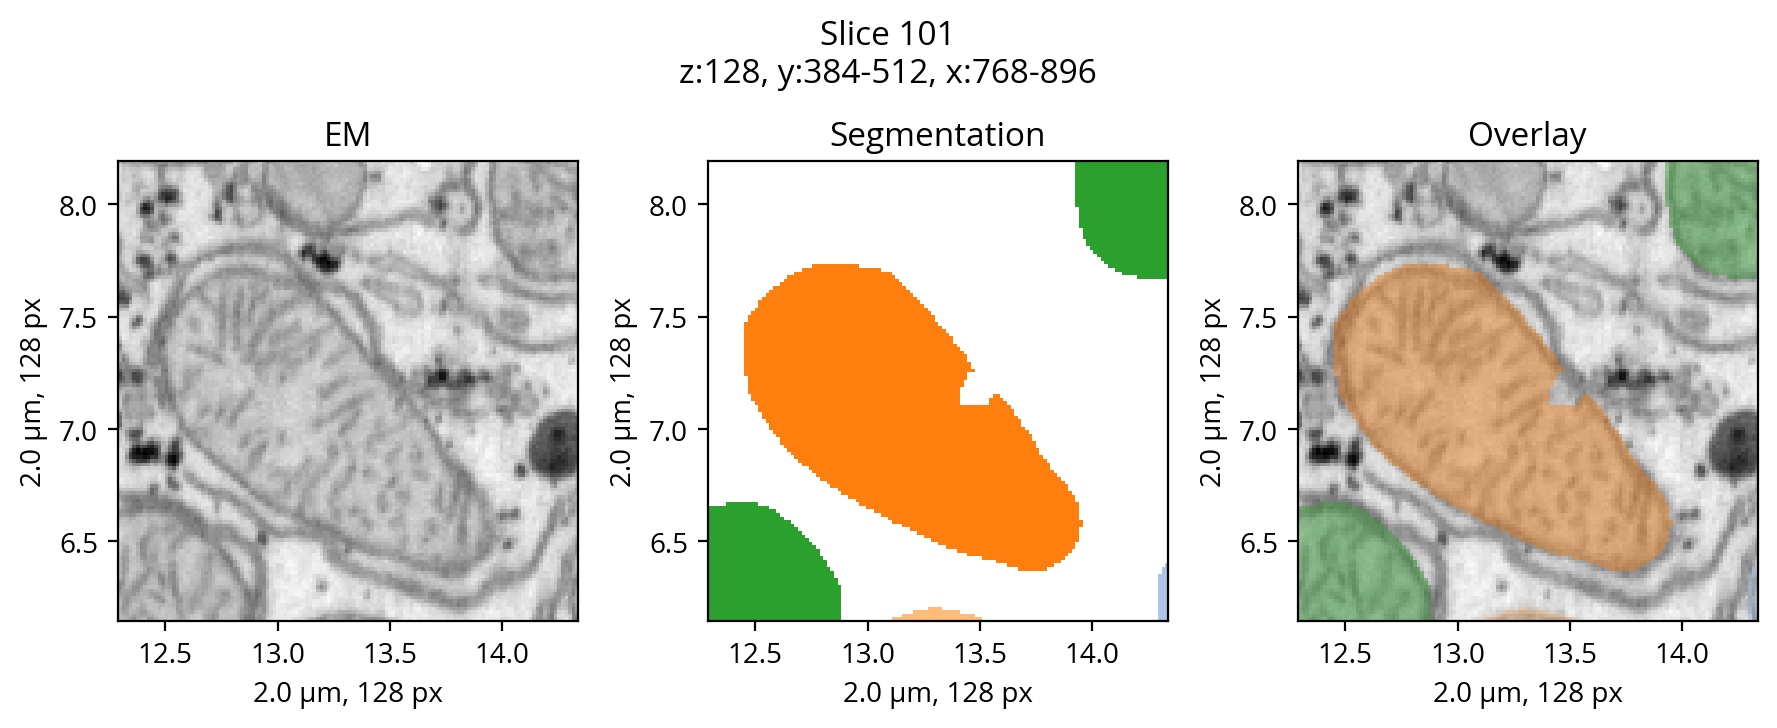

In [6]:
from src.visualizer import Visualizer
vis = Visualizer(data_manager)

slice_index = 101
slc = slices[slice_index]

z_index_to_plot = slc.z.start

# 2D plot — pick any z index within the slice bounds                                                                                    
vis.plot_segmentation_example(slc, z_index=z_index_to_plot, title=f"Slice {slice_index}\n"
    f"z:{slc.z.start}, y:{slc.y.start}-{slc.y.stop}, x:{slc.x.start}-{slc.x.stop}")


In [7]:
import torch
import numpy as np

def load_data_for_dino(data_manager, slc):
    # Run DINOv3 on the image slices to compute embeddings
    
    img = data_manager.em_data.data.isel(
        z=slc.z.start,
        y=slc.y,
        x=slc.x,
    ).compute()
    
    # da is your xarray DataArray with shape (H, W)
    arr = img.values  # (128, 128) numpy array
    
    # Normalize to [0, 1] first if your data isn't already
    arr = (arr - arr.min()) / (arr.max() - arr.min())
    
    # Replicate to 3 channels and convert to tensor: (1, 3, 128, 128)
    arr_3ch = np.stack([arr, arr, arr], axis=0)          # (3, 128, 128)
    x = torch.tensor(arr_3ch, dtype=torch.float32).unsqueeze(0)  # (1, 3, 128, 128)
    
    # Apply ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
    x = (x - mean) / std
    return x


In [8]:
import torch

REPO_DIR = "/Users/trung/Projects/dinov3/"
WEIGHTS  = "/Users/trung/Projects/dino_models/dinov3_vitl16_pretrain_lvd1689m.pth"

# Use vits16 to match embed_dim=384, 12 blocks
model = torch.hub.load(REPO_DIR, "dinov3_vits16", source="local", pretrained=False)

state_dict = torch.load(WEIGHTS, map_location="cpu")

model.load_state_dict(state_dict, strict=True)
#model.eval()

<All keys matched successfully>

In [9]:
def compute_patch_embeddings(model, x):
    import torch
    from PIL import Image
    from torchvision import transforms
    
    with torch.no_grad():
        out = model.forward_features(x)

    return out
    

In [10]:
def compute_dense(out):
    patch_tokens = out["x_norm_patchtokens"]          # (1, 64, 384)
    patch_map = patch_tokens.reshape(1, 384, 8, 8)    # (1, 384, 8, 8)
    
    dense = torch.nn.functional.interpolate(
        patch_map, size=(128, 128),
        mode="bilinear", align_corners=False
    )                                                  # (1, 384, 128, 128)
    dense = torch.nn.functional.normalize(dense, dim=1)  # L2 norm per pixel
    return dense

In [11]:

n = len(slices)

embeddings = []
all_dense_maps = []

for i, slc in enumerate(slices):
    x = load_data_for_dino(data_manager, slc)
    out = compute_patch_embeddings(model, x)
    embeddings.append(out)

    dense_map = compute_dense(out)
    all_dense_maps.append(dense_map)
    
    if i % 2 == 0:
        print(f"{i}/{n}")

    if i == 10:
        break

0/76032
2/76032
4/76032
6/76032
8/76032
10/76032


In [17]:
d = 384
vectors = []

# Add all patch vectors from all images
for dense_map in all_dense_maps:
    patches = dense_map.permute(2, 3, 0, 1).reshape(-1, 384).numpy()
    vectors.append(patches)

In [23]:
import hnswlib
import numpy as np

dim = 384
max_elements = 10_000_000  # set this to your expected upper bound

# Initialize index
index = hnswlib.Index(space='ip', dim=dim)  # ip = inner product
index.init_index(max_elements=max_elements, ef_construction=200, M=16)
index.set_ef(50)  # controls query-time accuracy/speed tradeoff

# Add your feature maps
for i, feature_map in enumerate(vectors):
    # feature_map: (16384, 384) numpy float32 array
    vectors = np.ascontiguousarray(feature_map.astype('float32'))
    #hnswlib.normalize(vectors)  # normalize for inner product similarity
    index.add_items(vectors)

print(f"Index size: {index.element_count} vectors")

Index size: 16384 vectors


In [28]:
# Your feature map: (1, 384, 128, 128)
feature_map = torch.randn(1, 384, 128, 128)

# Pick a spatial location (row=10, col=20)
row, col = 10, 20
query_patch = feature_map[0, :, row, col]         # (384,)
query_patch = query_patch.numpy().astype('float32')  # (384,)
query_patch = np.ascontiguousarray(query_patch).reshape(1, -1)  # (1, 384)

#hnswlib.normalize(query_patch)
labels, distances = index.knn_query(query_patch, k=5)

labels

array([[15439, 15951, 16079, 16207, 16335]], dtype=uint64)